# Antisense transcription calling
June 9, 2025

Examine the non-sense transcription for various windows of the genome to motivate the need/procedure for calling non-sense transcripts that may be cell cycle-regulated.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [216]:
from src.sgd import read_sgd_genes, read_nondubious_genes_dataset, load_origins_sgd
from src.orf_plotter import load_default_orf_plotter

orf_plotter = load_default_orf_plotter()


In [259]:
chrom = 16

In [420]:
# Load the RNA_seq for chromosome 1, and compute pileup for plotting
from src.timer import Timer
from src.read_bam import read_rna_bam, get_rna_seq_filepaths_df

rna_filepaths_df = get_rna_seq_filepaths_df().set_index(['replicate', 'time'])

def load_all_chrom_reads(rna_filepaths_df, replicate, chrom):
    timer = Timer()

    # Load the first time point
    all_chrom_reads_arr = []
    i = 0
    replicate_filepaths = rna_filepaths_df.loc[replicate]
    for timepoint, row in replicate_filepaths.iterrows():
        time_rna_reads = read_rna_bam(row.full_path)
        single_chrom_reads = time_rna_reads[time_rna_reads['chr'] == chrom].copy()
        single_chrom_reads['sample'] = timepoint
        all_chrom_reads_arr.append(single_chrom_reads)
        timer.print_time(f"{i}/{len(replicate_filepaths)}")
        i += 1

        # Conserve memory
        del time_rna_reads

    all_chrom_reads = pd.concat(all_chrom_reads_arr)
    return all_chrom_reads

all_chrom_reads_rep2 = load_all_chrom_reads(rna_filepaths_df, 2, chrom)
all_chrom_reads_rep1 = load_all_chrom_reads(rna_filepaths_df, 1, chrom)

0/14 - 00:01:21.234
1/14 - 00:02:20.266
2/14 - 00:03:45.623
3/14 - 00:04:58.029
4/14 - 00:06:09.859
5/14 - 00:07:31.383
6/14 - 00:08:12.973
7/14 - 00:10:22.747
8/14 - 00:11:34.499
9/14 - 00:12:58.773
10/14 - 00:14:32.843
11/14 - 00:16:02.392
12/14 - 00:17:30.929
13/14 - 00:19:00.060


In [870]:
from src.global_config import GlobalConstants

def compute_pileups(all_chrom_reads, span, replicate, smooth=False):
    
    within_span_reads = all_chrom_reads[(all_chrom_reads['start'] < span[1]) & 
                                    (all_chrom_reads['stop'] > span[0])]

    bins = np.linspace(span[0], span[1], span[1]-span[0]+1)

    if replicate == 1:
        timepoints = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
    else:
        timepoints = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS

    all_watson_pileups_per_time = []
    all_crick_pileups_per_time = []

    for time in timepoints:
        timepoint_reads = within_span_reads[within_span_reads['sample'] == time]
        watson_reads = timepoint_reads[timepoint_reads.strand == '+']
        crick_reads = timepoint_reads[timepoint_reads.strand == '-']

        watson_counts, bin_boundaries = np.histogram(watson_reads['start'], bins=bins)
        watson_df = pd.DataFrame(watson_counts).T
        watson_df.index = [time]

        crick_counts, bin_boundaries = np.histogram(crick_reads['start'], bins=bins)
        crick_df = pd.DataFrame(crick_counts).T
        crick_df.index = [time]

        all_watson_pileups_per_time.append(watson_df)
        all_crick_pileups_per_time.append(crick_df)

    watson_pileups_df = pd.concat(all_watson_pileups_per_time)
    crick_pileups_df = pd.concat(all_crick_pileups_per_time)
    
    if smooth:
        smooth_watson_pileups_df = watson_pileups_df.copy()
        smooth_crick_pileups_df = crick_pileups_df.copy()
        
        if replicate == 1:
            timepoints = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
        else:
            timepoints = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS

        for i, time in enumerate(timepoints):
            w_time_pileups = watson_pileups_df.loc[time]
            c_time_pileups = crick_pileups_df.loc[time]

            w_time_pileups = smooth_rna_curve(w_time_pileups)
            c_time_pileups = smooth_rna_curve(c_time_pileups)
            
            smooth_watson_pileups_df.loc[time] = w_time_pileups
            smooth_crick_pileups_df.loc[time] = c_time_pileups
        
        watson_pileups_df = smooth_watson_pileups_df
        crick_pileups_df = smooth_crick_pileups_df
    
    return watson_pileups_df, crick_pileups_df, bin_boundaries

In [871]:
def load_smoothing_kernel(plot=False):
    n = 50
    xs = np.linspace(-n//2, n//2+1, n)
    kernel = norm.pdf(xs, 0, 8)
    kernel = kernel/kernel.max()

    if plot:
        plt.plot(xs, kernel)
    return kernel

def smooth_rna_curve(input_pileup, plot_kernel=False):
    kernel = load_smoothing_kernel()
    smoothed_pileup = np.convolve(input_pileup, kernel, mode='same')
    return smoothed_pileup

array([0.0075757 , 0.01128023, 0.01651437, 0.0237714 , 0.03364314,
       0.04681523, 0.06405112, 0.08616189, 0.11396003, 0.14819679,
       0.1894846 , 0.23820888, 0.29443598, 0.35782668, 0.42756627,
       0.502323  , 0.58024523, 0.65900543, 0.73589407, 0.80796121,
       0.87219706, 0.92573699, 0.96607204, 0.9912434 , 1.        ,
       0.99190159, 0.96735543, 0.9275823 , 0.87451594, 0.81064723,
       0.73883077, 0.66207462, 0.58333469, 0.50533289, 0.43041384,
       0.36044896, 0.29679066, 0.24027333, 0.19125369, 0.14967972,
       0.1151768 , 0.08713967, 0.06482101, 0.0474094 , 0.03409276,
       0.02410508, 0.0167573 , 0.01145377, 0.00769736, 0.00508609])

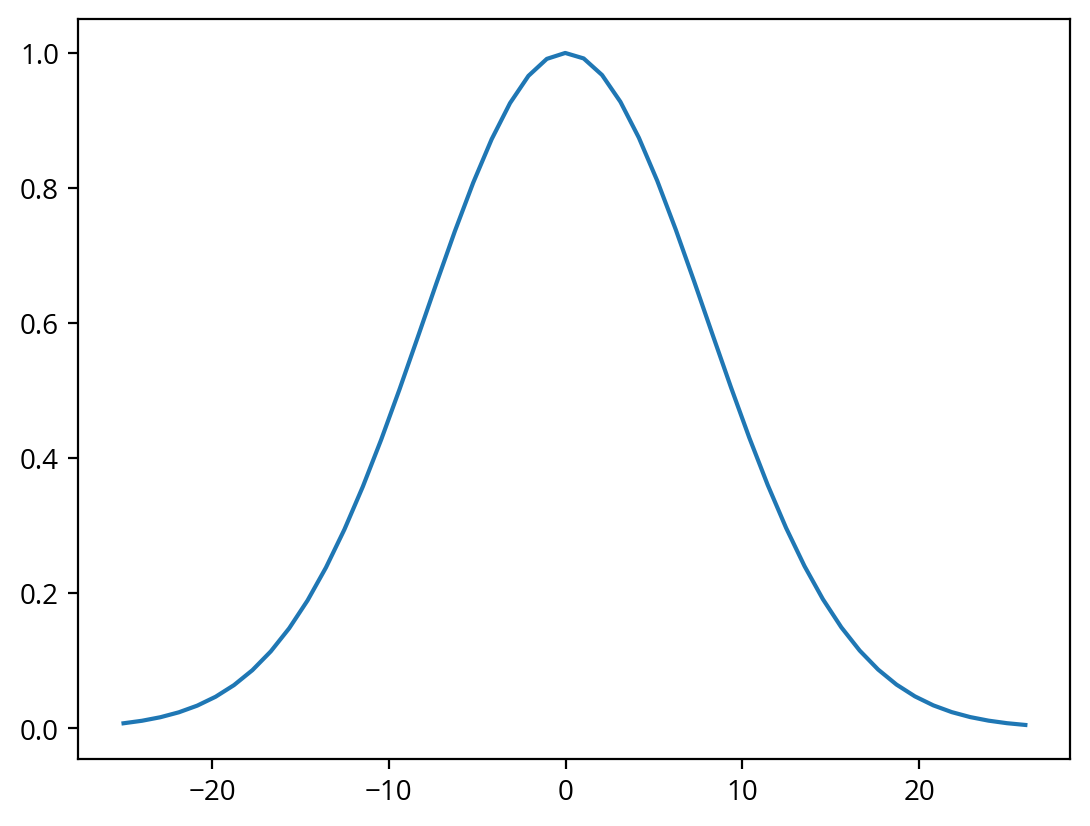

In [872]:
load_smoothing_kernel(True)

In [873]:

def plot_rna_at_region(span, chrom, all_chrom_reads, replicate):
    orf_plotter.set_span_chrom(span, chrom)
    
    watson_pileups_df, crick_pileups_df, bin_boundaries = \
        compute_pileups(all_chrom_reads, span, replicate, smooth=True)
    
    from scipy.stats.distributions import norm

    # Smoothing kernel
    xs = np.linspace(-5, 5, 10)
    kernel = norm.pdf(xs, 0, 1)
    kernel = kernel/kernel.max()

    plt.figure(figsize=(18, 2))
    plt.subplot(2, 1, 1)
    ax = plt.gca()
    orf_plotter.plot_orf_annotations(ax)

    plt.subplot(2, 1, 2)

    moving_avg_kernel = np.ones(6)/6
    
    if replicate == 1:
        timepoints = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
    else:
        timepoints = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS
        
    for i, time in enumerate(timepoints):
        w_time_pileups = watson_pileups_df.loc[time]
        c_time_pileups = crick_pileups_df.loc[time]

        plt.plot(bin_boundaries[:-1], np.log2(w_time_pileups+1), 
                 c=plt.cm.Blues(i/len(timepoints)), lw=0.5)
        plt.plot(bin_boundaries[:-1], -np.log2(c_time_pileups+1), 
                 c=plt.cm.Reds(i/len(timepoints)), lw=0.5)

    plt.xlim(span[0], span[1])
    plt.axhline(0, c='black', lw=1, zorder=0)
    plt.ylim(-17, 17)

In [874]:
clb5_div_antisense_span = selection_span

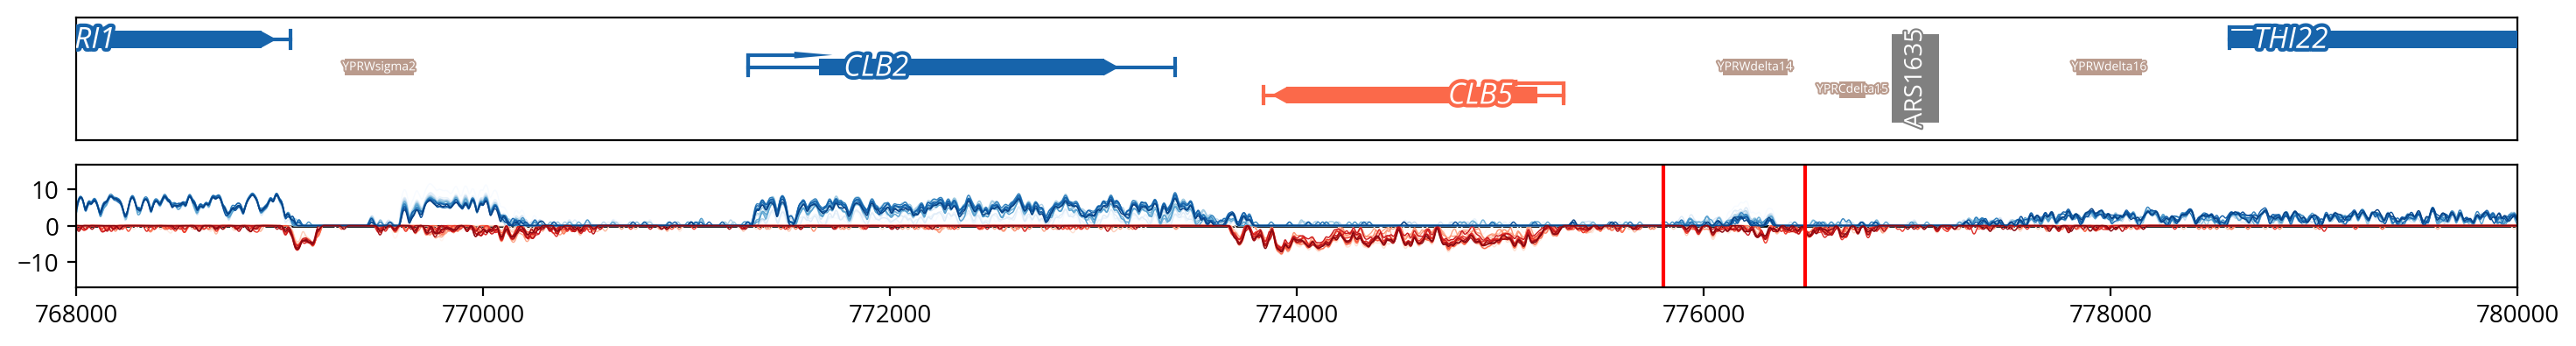

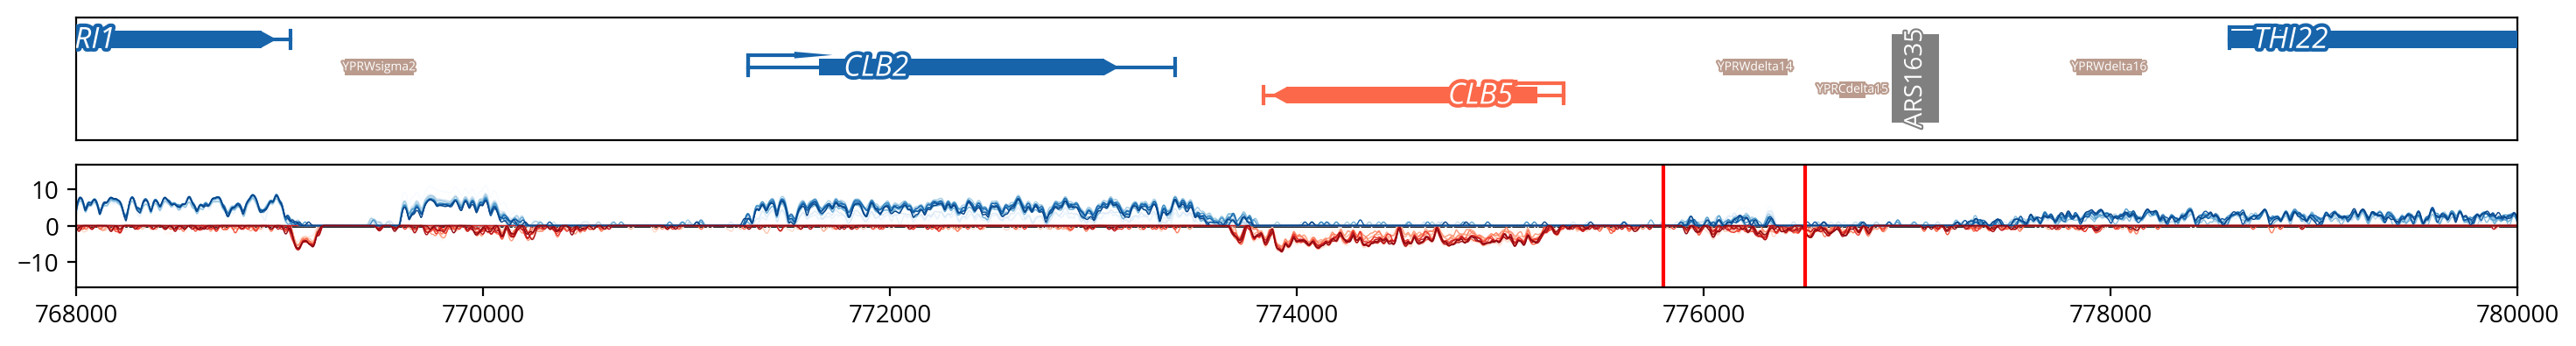

In [875]:
chrom = 16
span = 768000, 780000

plot_rna_at_region(span, chrom, all_chrom_reads_rep1, replicate=1)

for s in clb5_div_antisense_span:
    plt.axvline(s, c='red')

plot_rna_at_region(span, chrom, all_chrom_reads_rep2, replicate=2)

for s in clb5_div_antisense_span:
    plt.axvline(s, c='red')

In [422]:
chrom_total_counts_rep1 = all_chrom_reads_rep1.groupby('sample').count()
chrom_total_counts_rep1 = chrom_total_counts_rep1[['stop']].rename(columns={'stop': 'count'})

chrom_total_counts_rep2 = all_chrom_reads_rep2.groupby('sample').count()
chrom_total_counts_rep2 = chrom_total_counts_rep2[['stop']].rename(columns={'stop': 'count'})

In [424]:
rna_norm_scalar1 = chrom_total_counts_rep1.max() /  chrom_total_counts_rep1
rna_norm_scalar2 = chrom_total_counts_rep2.max() /  chrom_total_counts_rep2

In [427]:
timepoints1 = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
timepoints2 = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS

In [537]:
def select_and_normalize_reads(all_chrom_reads_rep1, all_chrom_reads_rep2, selection_span,
                              strand):
    selected_reads1 = all_chrom_reads_rep1[(all_chrom_reads_rep1.stop > selection_span[0]) & 
                                     (all_chrom_reads_rep1.start < selection_span[1]) & 
                                     (all_chrom_reads_rep1.strand == strand)]

    selected_reads2 = all_chrom_reads_rep2[(all_chrom_reads_rep2.stop > selection_span[0]) & 
                                     (all_chrom_reads_rep2.start < selection_span[1]) & 
                                     (all_chrom_reads_rep2.strand == strand)]

    # Normalize by the total reads of the chromosome
    normed_selected_reads1 = selected_reads1.groupby('sample').count().stop.values*\
        rna_norm_scalar1.values.flatten()

    normed_selected_reads2 = selected_reads2.groupby('sample').count().stop.values*\
        rna_norm_scalar2.values.flatten()
    return normed_selected_reads1, normed_selected_reads2

In [541]:
normed_selected_reads1_w, normed_selected_reads2_w = \
    select_and_normalize_reads(all_chrom_reads_rep1,
    all_chrom_reads_rep2,
    selection_span,
    '+')

normed_selected_reads1_c, normed_selected_reads2_c = \
    select_and_normalize_reads(all_chrom_reads_rep1,
    all_chrom_reads_rep2,
    selection_span,
    '-')

(0.0, 11.0)

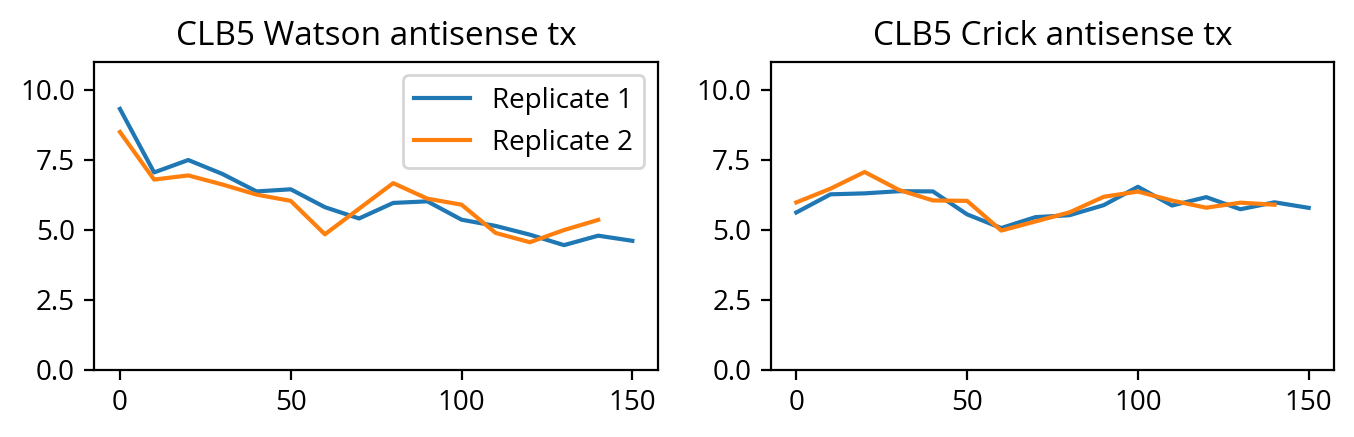

In [596]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(timepoints1, np.log2(normed_selected_reads1_w+1), label="Replicate 1")
plt.plot(timepoints2, np.log2(normed_selected_reads2_w+1), label="Replicate 2")
plt.title("CLB5 Watson antisense tx")
plt.ylim(0, 11)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(timepoints1, np.log2(normed_selected_reads1_c+1))
plt.plot(timepoints2, np.log2(normed_selected_reads2_c+1))
plt.title("CLB5 Crick antisense tx")
plt.ylim(0, 11)

In [432]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner
output_directory = 'output/draft3_run/'
expression_deconv_runner = CombinedDeconvolveGeneExpressionRunner(output_directory)

In [ ]:
expression_deconv_runner.

In [625]:
kappa = 0.001
eta = 1
expression_deconv_runner.deconvolve_gene_optimal_gamma('CLB5', kappa=kappa, eta=eta)
clb5_tx_F = expression_deconv_runner.retrieve_solution()

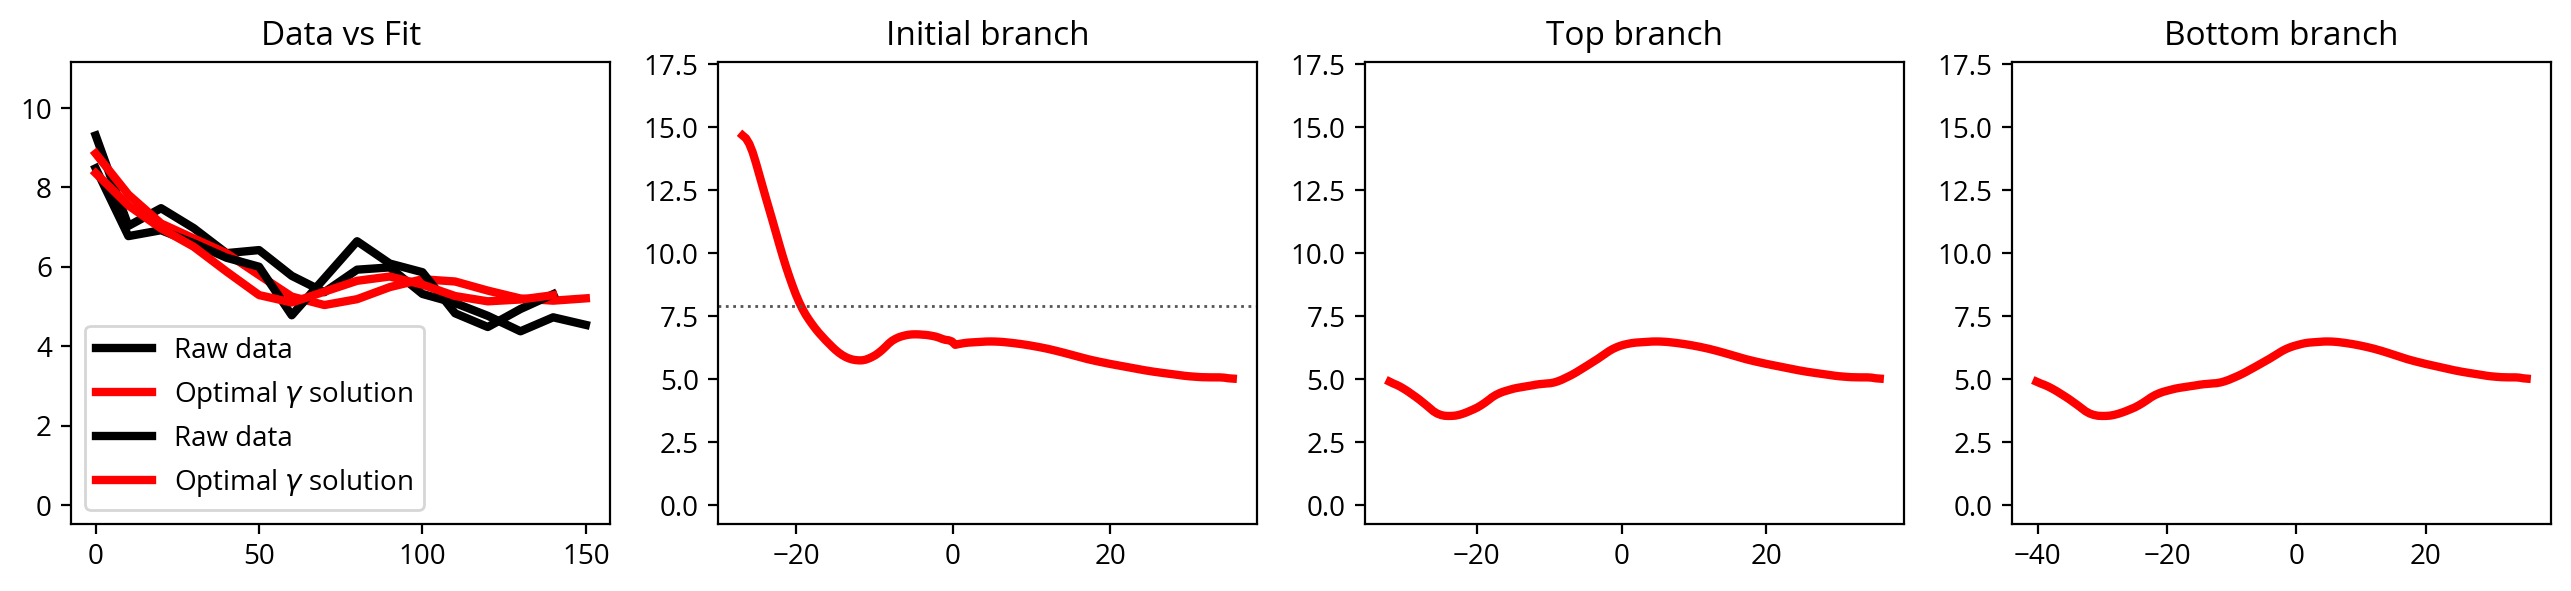

In [587]:
antisense_G_w = np.log2(np.concatenate([normed_selected_reads1_w, normed_selected_reads2_w]))
expression_deconv_runner.deconvolve_G_optimal_gamma(antisense_G_w,
                                                   kappa=kappa, eta=eta)
clb5_antisense_tx_w_F = expression_deconv_runner.retrieve_solution()

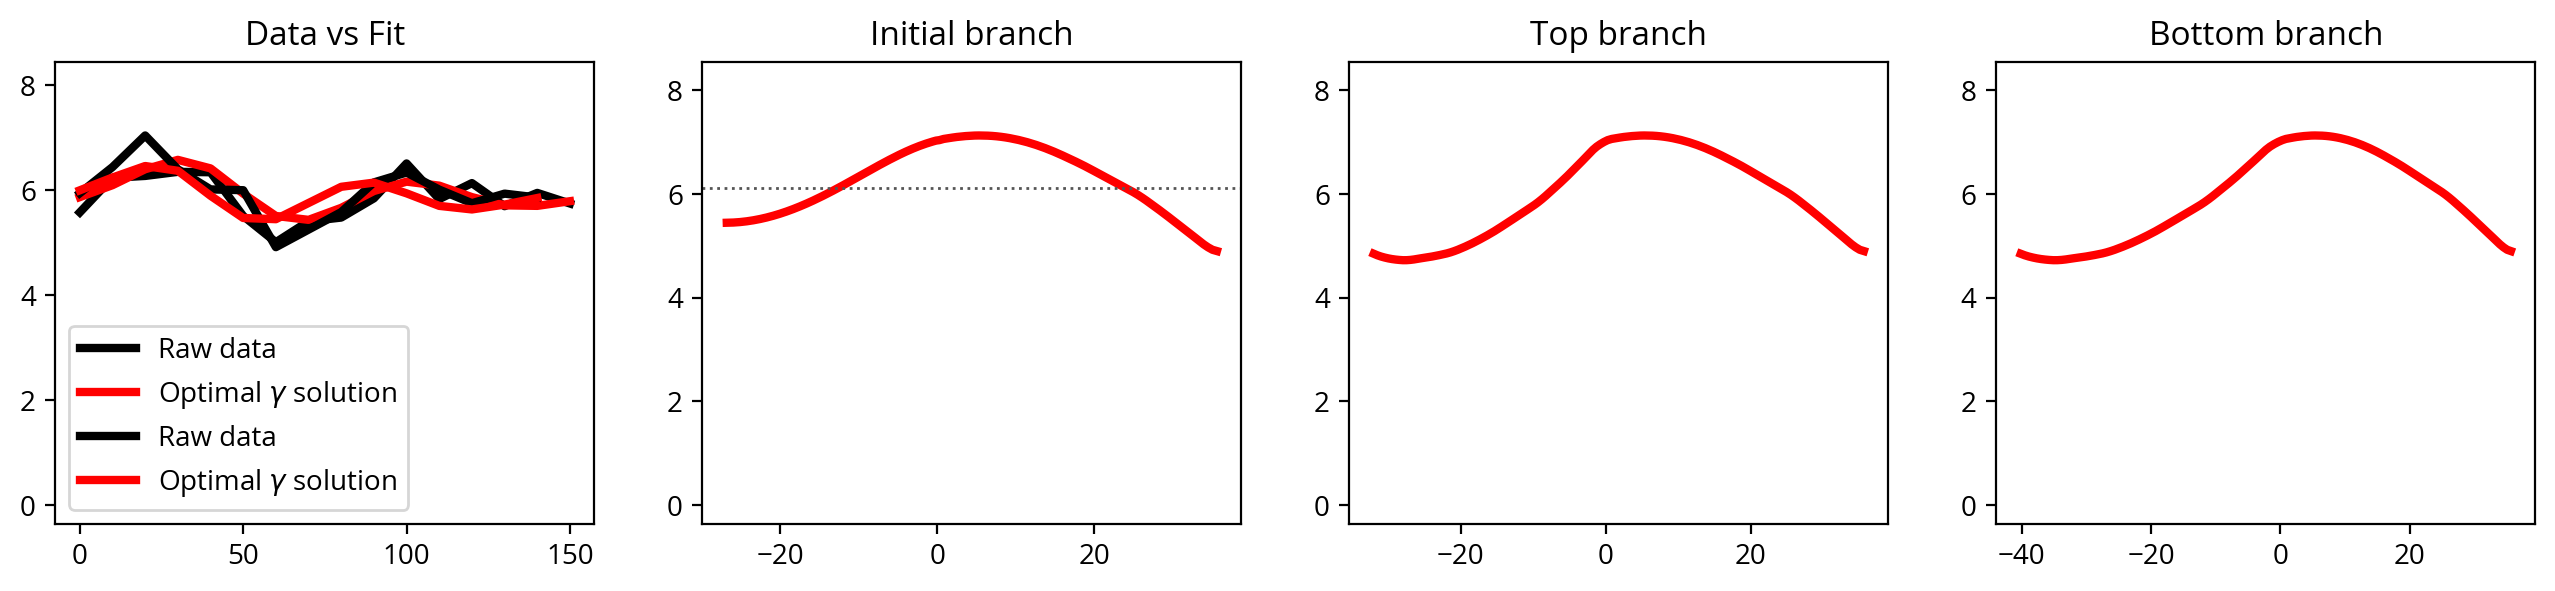

In [588]:
antisense_G_c = np.log2(np.concatenate([normed_selected_reads1_c, normed_selected_reads2_c]))
expression_deconv_runner.deconvolve_G_optimal_gamma(G=antisense_G_c,
                                                   kappa=kappa, eta=eta)
clb5_antisense_tx_c_F = expression_deconv_runner.retrieve_solution()

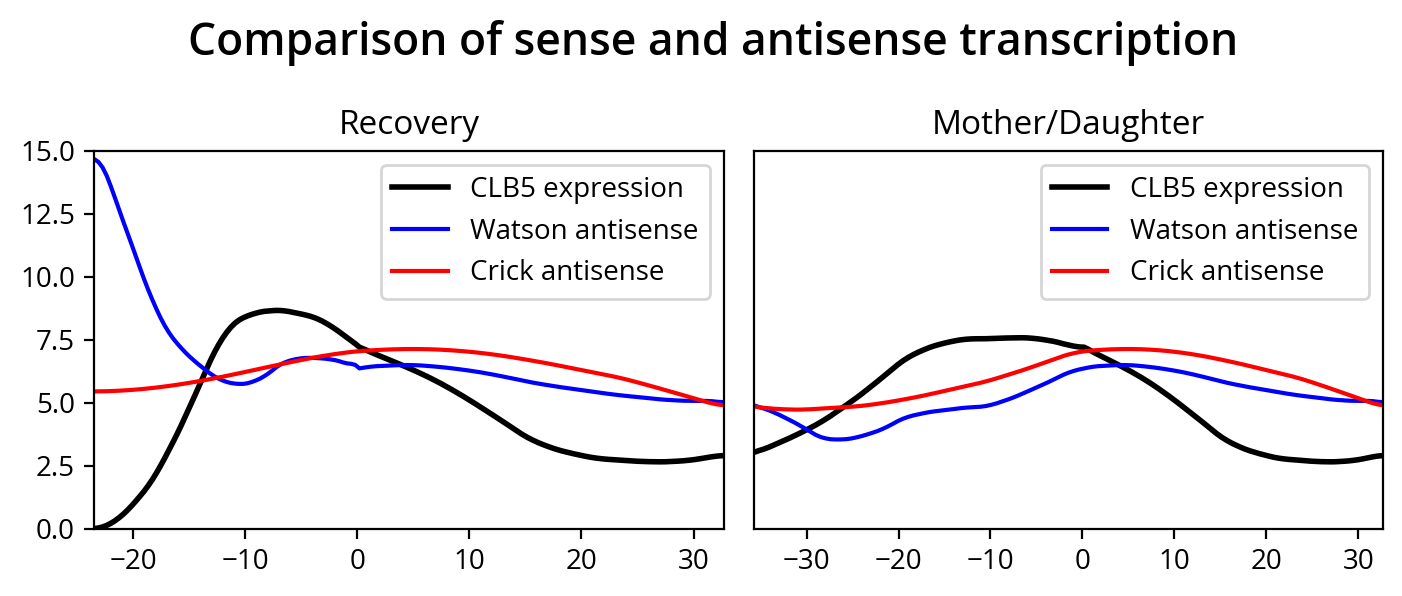

In [624]:
from src.config import get_average_timepoints_for_branch, load_default_expression_configs
config1, config2 = load_default_expression_configs()

def plot_comparison_branch(branch, branch_name):

    if branch == 'tb':
        t_tps = get_average_timepoints_for_branch(config1, config2, 't')
        b_tps = get_average_timepoints_for_branch(config1, config2, 'b')
        f_tps = (t_tps + b_tps)/2.
        t_indices = config.t_indices()
        b_indices = config.b_indices()
        expression = (clb5_tx_F[t_indices]+clb5_tx_F[b_indices])/2.
        
        antisense_w = (clb5_antisense_tx_w_F[t_indices]+clb5_antisense_tx_w_F[b_indices])/2.
        antisense_c = (clb5_antisense_tx_c_F[t_indices]+clb5_antisense_tx_c_F[b_indices])/2.
    else:
        f_tps = get_average_timepoints_for_branch(config1, config2, branch)
        indices = config.get_Hpositions_for_branch(branch)
        expression = clb5_tx_F[indices]
        antisense_w = clb5_antisense_tx_w_F[indices]
        antisense_c = clb5_antisense_tx_c_F[indices]
    
    plt.plot(f_tps, expression, lw=2, label="CLB5 expression", c='black')
    plt.plot(f_tps, antisense_w, label="Watson antisense", c='blue')
    plt.plot(f_tps, antisense_c,label="Crick antisense", c='red')
    plt.ylim(0, 15)
    plt.legend()
    plt.title(branch_name)
    plt.xlim(f_tps[0], f_tps[-1])
    
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plot_comparison_branch('i', 'Recovery')

plt.subplot(1, 2, 2)
plot_comparison_branch('tb', 'Mother/Daughter')
plt.yticks([])

plt.suptitle("Comparison of sense and antisense transcription", fontweight='demi',
            fontsize=16)
plt.tight_layout()


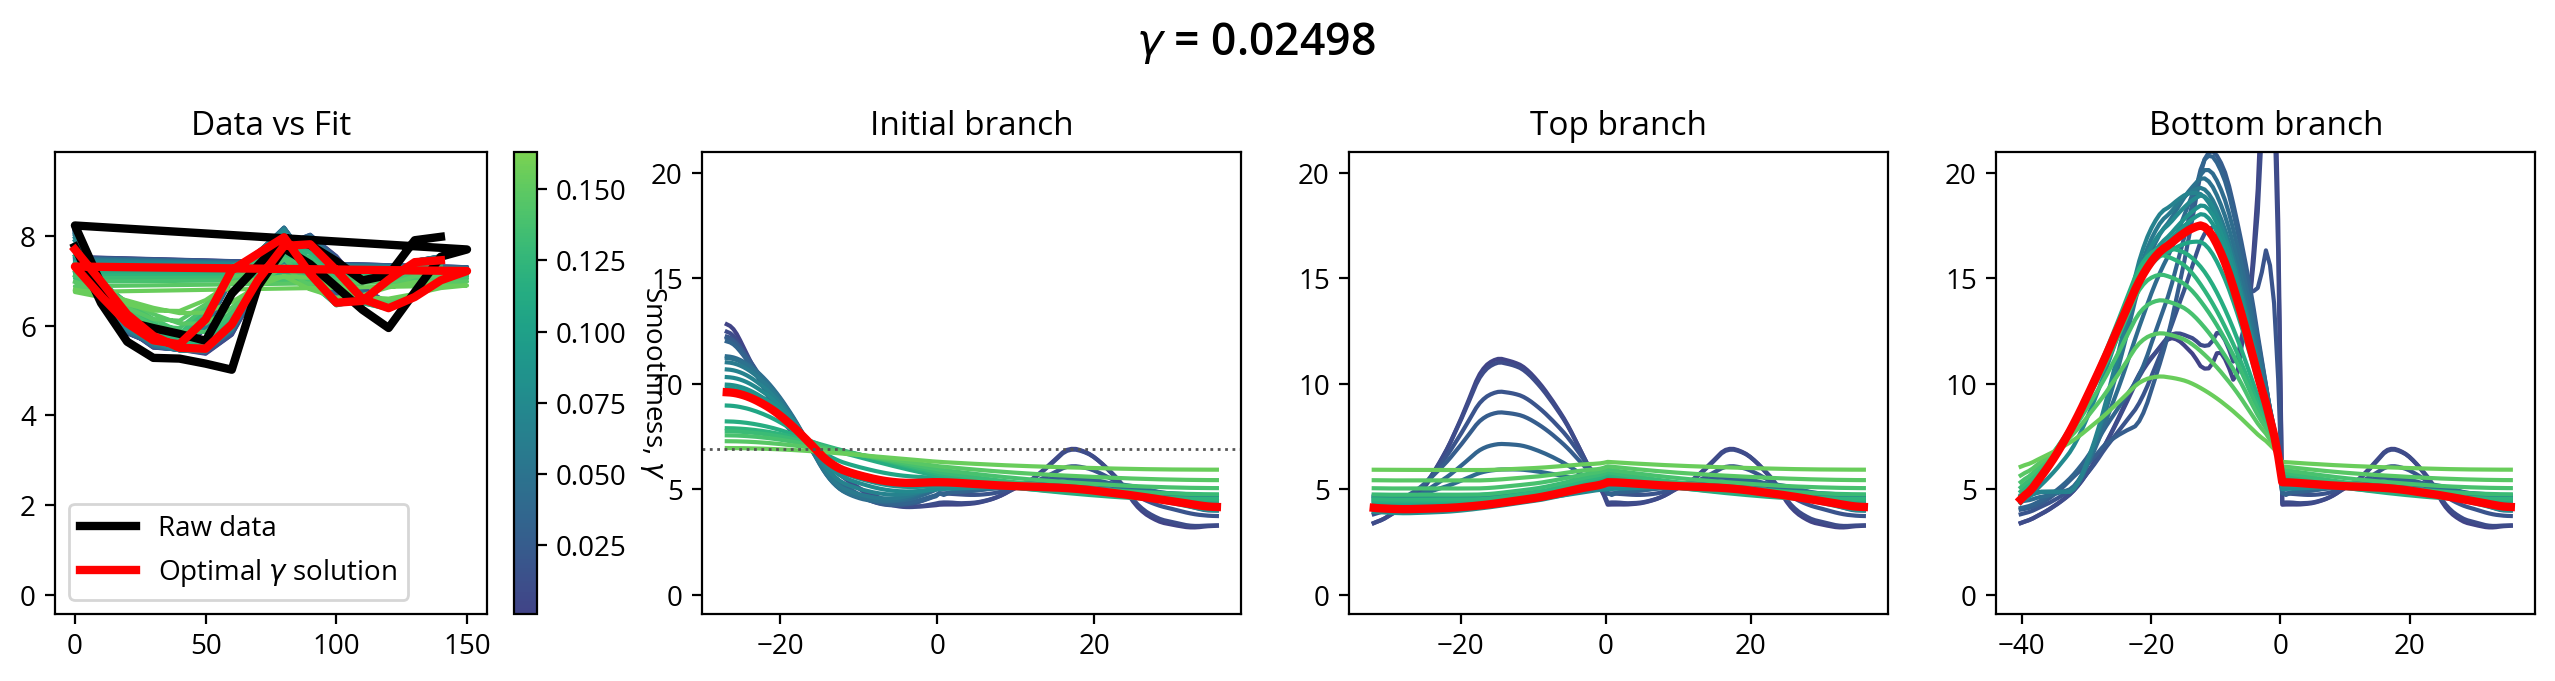

In [590]:
expression_deconv_runner.deconvolve_gene_optimal_gamma('DSE1', kappa=kappa, eta=eta)
fig = expression_deconv_runner.expression_find_gamma.plot_gamma_sweep()

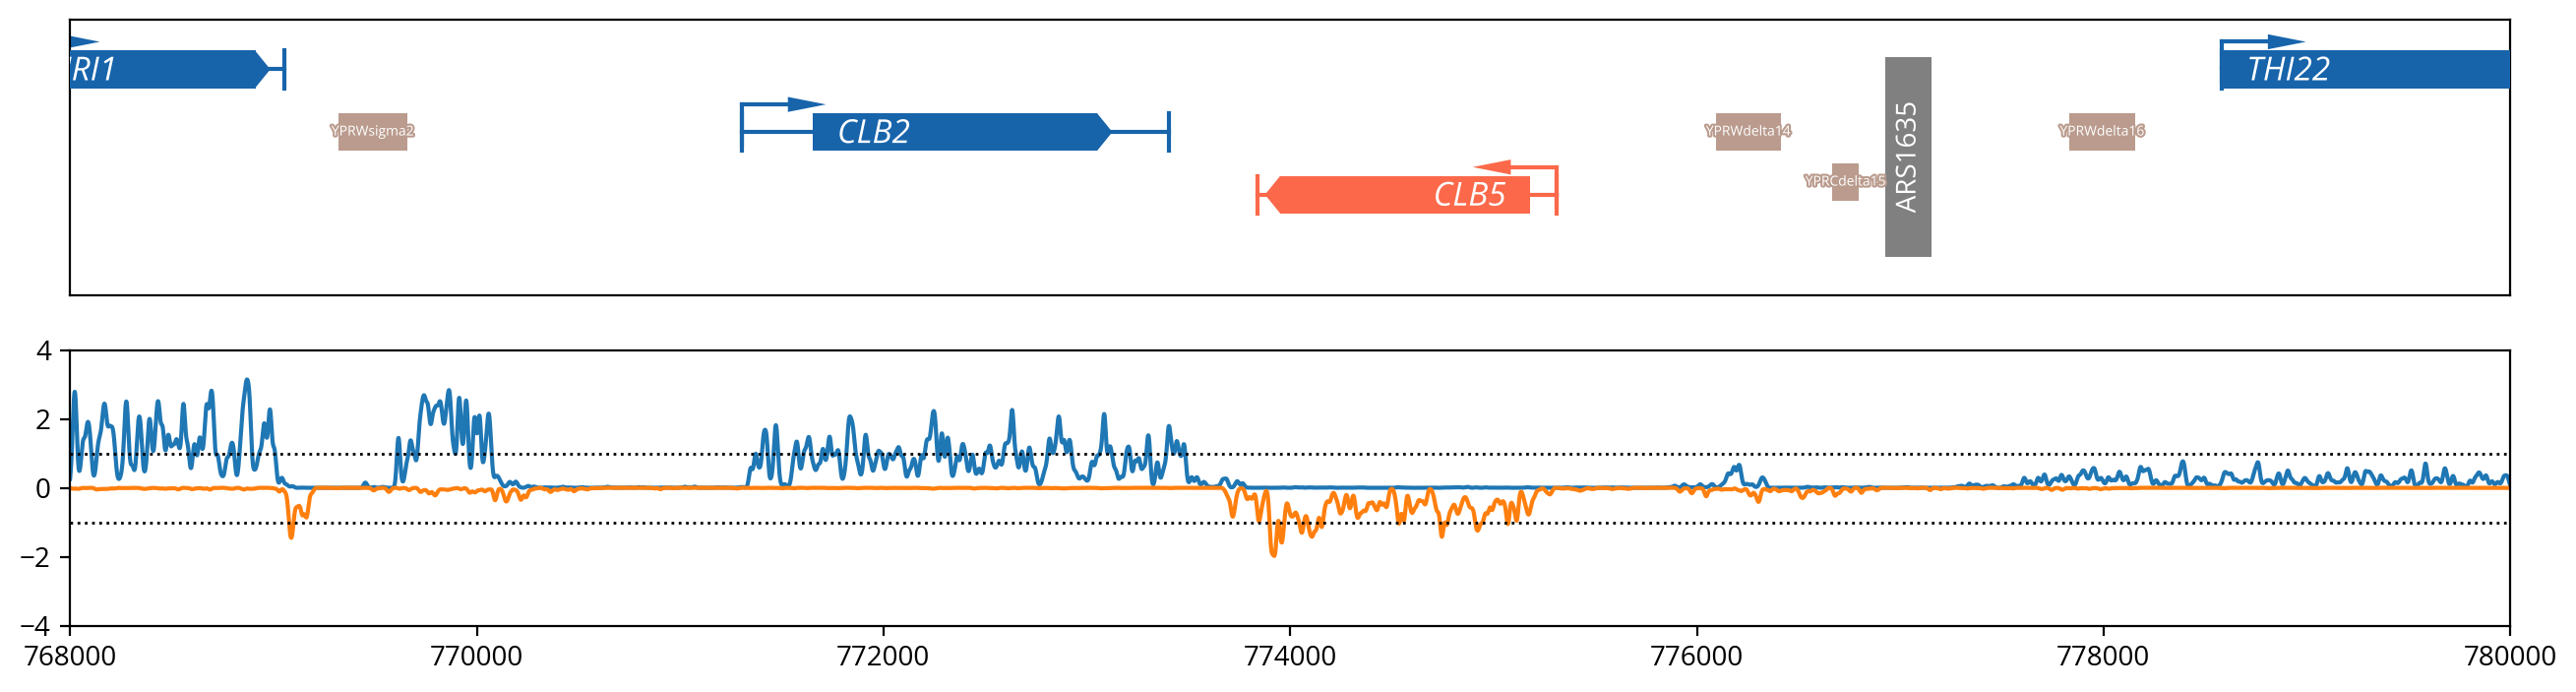

In [800]:
# Story is established that antisense transcript is worth analyzing. Thus, 
# a comprehensive way to identify transcripts is needed. Let's start by ignoring
# gene annotations and identifying transcripts.
from src.transcription import filter_rna_seq

within_span_reads = \
    filter_rna_seq(all_chrom_reads_rep1, span[0], span[1], chrom=chrom)

watson_total_pileup, crick_total_pileup, bin_boundaries = compute_pileups(all_chrom_reads_rep1, 
    span, 1)

w_log_pileup = np.log2(watson_total_pileup.mean(0)+1).values
c_log_pileup = np.log2(crick_total_pileup.mean(0)+1).values

w_log_pileup = smooth_rna_curve(w_log_pileup)
c_log_pileup = smooth_rna_curve(c_log_pileup)

plt.figure(figsize=(16, 4))
plt.subplot(2, 1, 1)
orf_plotter.plot_orf_annotations(plt.gca())

plt.subplot(2, 1, 2)
plt.plot(bin_boundaries[:-1], w_log_pileup)
plt.plot(bin_boundaries[:-1], -c_log_pileup)
plt.ylim(-4, 4)
plt.xlim(span[0], span[1])

plt.axhline(1, lw=1, c='black', ls='dotted')
plt.axhline(-1, lw=1, c='black', ls='dotted')

In [681]:
import numpy as np
from typing import List, Tuple

def find_transcript_boundaries(pileup_values: np.ndarray, 
                             primary_threshold: float = 3.0,
                             extension_threshold: float = 1.5,
                             min_length: int = 100,
                             max_gap: int = 50) -> List[Tuple[int, int]]:
    """
    Identify transcript boundaries using a two-threshold approach.
    
    Parameters:
    -----------
    pileup_values : np.ndarray
        1D array of smoothed pileup coverage values
    primary_threshold : float
        Higher threshold for identifying transcript cores
    extension_threshold : float  
        Lower threshold for extending transcript boundaries
    min_length : int
        Minimum transcript length in base pairs
    max_gap : int
        Maximum gap size to merge nearby regions
        
    Returns:
    --------
    List[Tuple[int, int]]
        List of (start, end) coordinates for identified transcripts
    """
    
    # Step 1: Find core regions above primary threshold
    core_mask = pileup_values >= primary_threshold
    core_regions = _get_regions_from_mask(core_mask)
    
    if not core_regions:
        return []
    
    # Step 2: Extend each core region using extension threshold
    extended_regions = []
    extension_mask = pileup_values >= extension_threshold
    
    for start, end in core_regions:
        # Extend left
        extended_start = start
        while extended_start > 0 and extension_mask[extended_start - 1]:
            extended_start -= 1
            
        # Extend right  
        extended_end = end
        while extended_end < len(pileup_values) - 1 and extension_mask[extended_end + 1]:
            extended_end += 1
            
        extended_regions.append((extended_start, extended_end))
    
    # Step 3: Merge overlapping or nearby regions
    merged_regions = _merge_nearby_regions(extended_regions, max_gap)
    
    # Step 4: Filter by minimum length
    final_regions = [(start, end) for start, end in merged_regions 
                    if (end - start + 1) >= min_length]
    
    return final_regions


def _get_regions_from_mask(mask: np.ndarray) -> List[Tuple[int, int]]:
    """Convert boolean mask to list of (start, end) regions."""
    if not np.any(mask):
        return []
    
    # Find transitions
    diff = np.diff(np.concatenate(([False], mask, [False])).astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    
    return list(zip(starts, ends))


def _merge_nearby_regions(regions: List[Tuple[int, int]], 
                         max_gap: int) -> List[Tuple[int, int]]:
    """Merge regions that are within max_gap of each other."""
    if not regions:
        return []
    
    # Sort regions by start position
    sorted_regions = sorted(regions)
    merged = [sorted_regions[0]]
    
    for current_start, current_end in sorted_regions[1:]:
        last_start, last_end = merged[-1]
        
        # Check if current region should be merged with the last one
        if current_start <= last_end + max_gap + 1:
            # Merge by extending the last region
            merged[-1] = (last_start, max(last_end, current_end))
        else:
            # Add as new region
            merged.append((current_start, current_end))
    
    return merged

In [ ]:
# Story is established that antisense transcript is worth analyzing. Thus, 
# a comprehensive way to identify transcripts is needed. Let's start by ignoring
# gene annotations and identifying transcripts.
from src.transcription import filter_rna_seq

within_span_reads = \
    filter_rna_seq(all_chrom_reads_rep1, span[0], span[1], chrom=chrom)

watson_total_pileup, crick_total_pileup, bin_boundaries = \
    compute_pileups(all_chrom_reads_rep1, 
    span, 1, smooth=True)

w_log_pileup = np.log2(watson_total_pileup.mean(0)+1).values
c_log_pileup = np.log2(crick_total_pileup.mean(0)+1).values

0

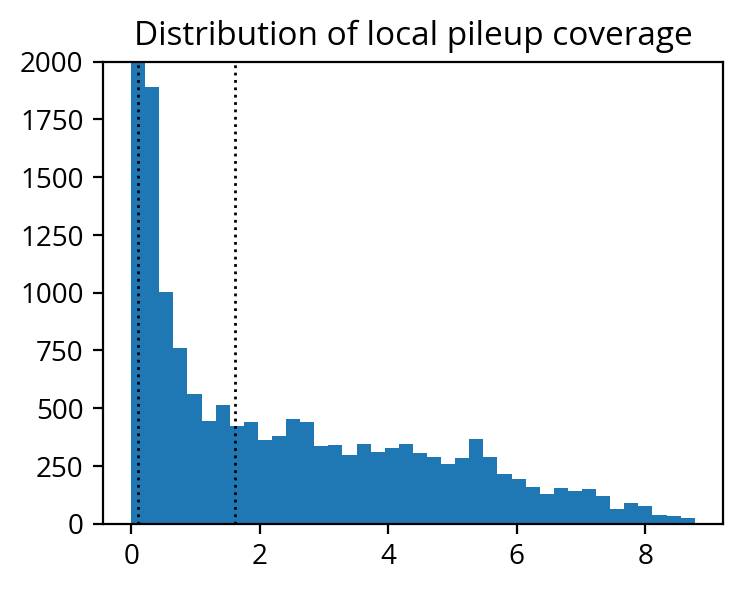

In [884]:
q75, q50 = np.quantile(w_log_pileup, q=0.50), np.quantile(w_log_pileup, q=0.25)

plt.figure(figsize=(4, 3))
plt.hist(np.concatenate([w_log_pileup, c_log_pileup]), bins=40)
plt.ylim(0, 2000)
plt.axvline(q75, c='black', ls='dotted', lw=1)
plt.axvline(q50, c='black', ls='dotted', lw=1)
plt.title("Distribution of local pileup coverage")
0


In [885]:
w_transcripts = find_transcript_boundaries(
    w_log_pileup, 
    primary_threshold=q75,
    extension_threshold=q50,
    min_length=100,
    max_gap=50
)

c_transcripts = find_transcript_boundaries(
    c_log_pileup, 
    primary_threshold=q75,
    extension_threshold=q50,
    min_length=100,
    max_gap=50
)

w_transcripts, c_transcripts

([(0, 1110), (1588, 2222), (3285, 5788), (7847, 8359), (9493, 11999)],
 [(990, 1210), (1703, 2303), (5664, 7303), (7894, 8907)])

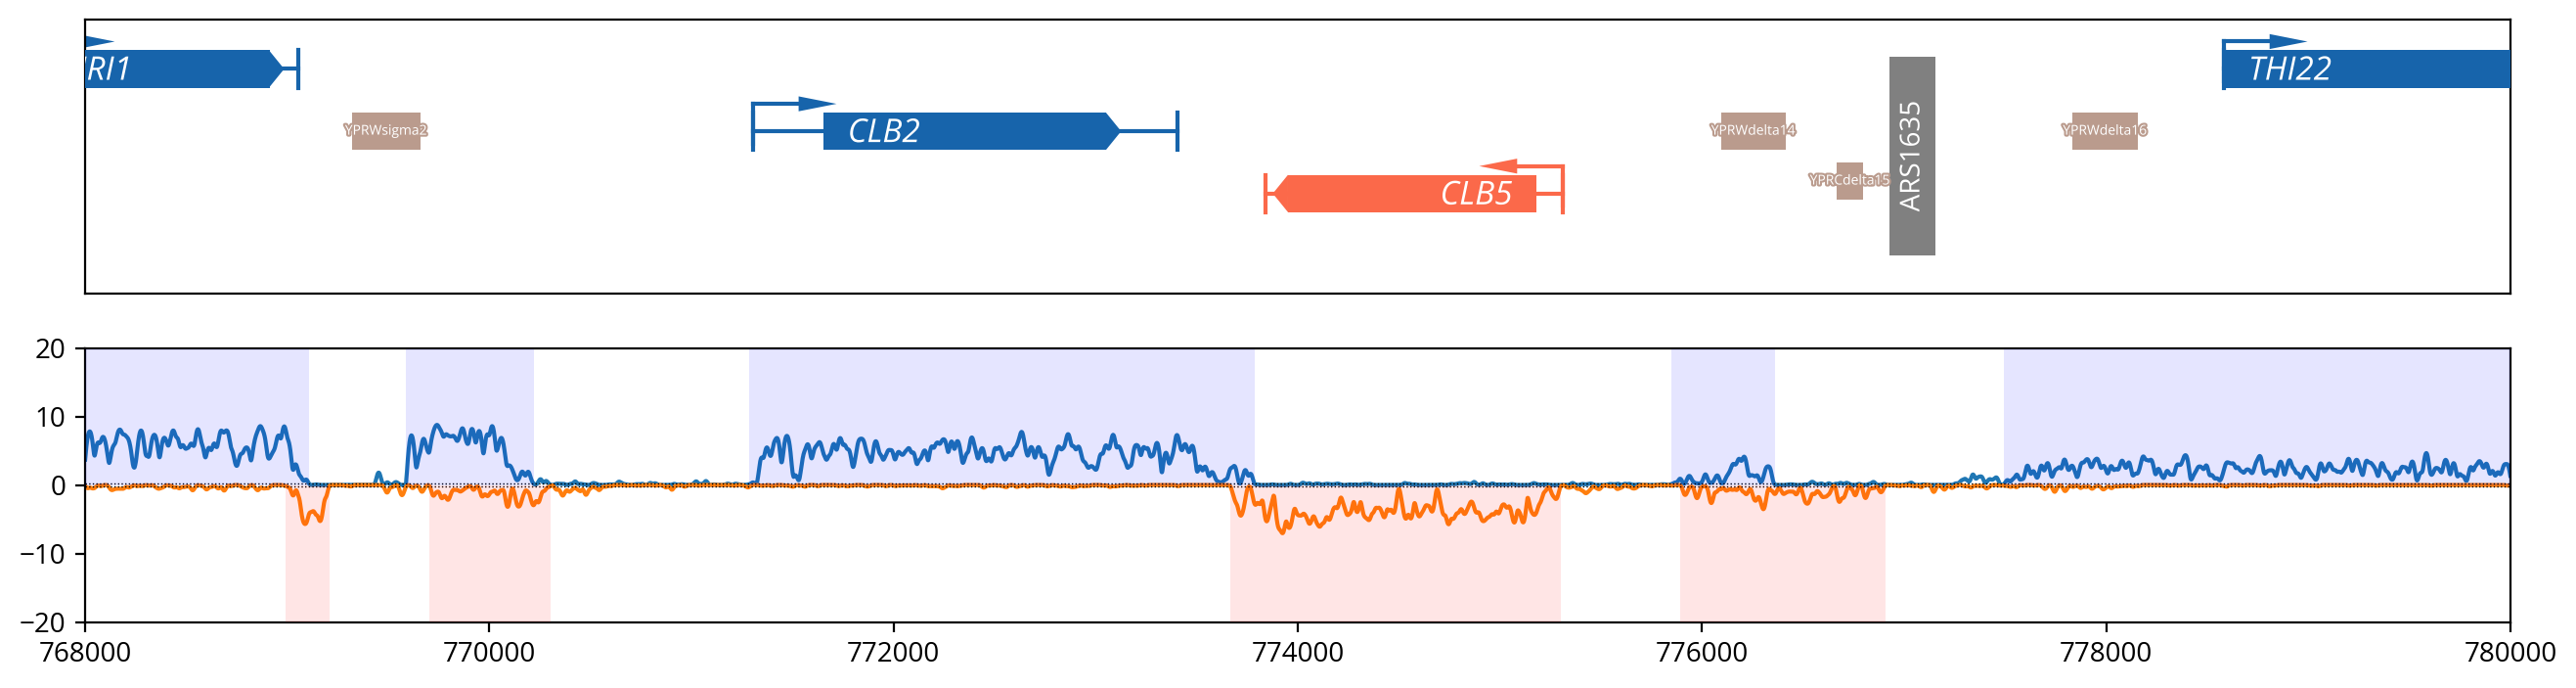

In [906]:
plt.figure(figsize=(16, 4))
plt.subplot(2, 1, 1)
orf_plotter.plot_orf_annotations(plt.gca())

plt.subplot(2, 1, 2)
plt.plot(bin_boundaries[:-1], w_log_pileup)
plt.plot(bin_boundaries[:-1], -c_log_pileup)
plt.ylim(-20, 20)
plt.xlim(span[0], span[1])

plt.axhline(0.25, lw=0.5, c='black', ls='dotted')
plt.axhline(-0.25, lw=0.5, c='black', ls='dotted')

from src.plot_helpers import plot_rect2

ax = plt.gca()
for called_span in w_transcripts:
    plot_rect2(ax, called_span[0]+span[0], 0, called_span[1]+span[0], 
               20, color='blue', alpha=0.1)
        
for called_span in c_transcripts:
    plot_rect2(ax, called_span[0]+span[0], 0, called_span[1]+span[0], 
               -20, color='red', alpha=0.1)


In [910]:
from src.timer import Timer

def compute_pileups_advanced(all_chrom_reads, span, replicate, smooth=False):
    """
    Even more optimized version using advanced numpy techniques.
    Use this if the basic optimization isn't fast enough.
    """
    timer = Timer()
    timer.print_time("Starting advanced pileup computation")
    
    # Filter and sort reads for cache efficiency
    within_span_reads = all_chrom_reads[(all_chrom_reads['start'] < span[1]) & 
                                        (all_chrom_reads['stop'] > span[0])].copy()
    within_span_reads = within_span_reads.sort_values('start')
    timer.print_time("Filtered and sorted reads")
    
    # Get timepoints
    timepoints = (GlobalConstants.EXPRESSION_WT1_TIMEPOINTS if replicate == 1 
                  else GlobalConstants.EXPRESSION_WT2_TIMEPOINTS)
    
    # Create timepoint and strand mappings for vectorized operations
    timepoint_map = {tp: i for i, tp in enumerate(timepoints)}
    within_span_reads['timepoint_idx'] = within_span_reads['sample'].map(timepoint_map)
    within_span_reads['strand_idx'] = (within_span_reads['strand'] == '+').astype(int)
    
    # Pre-allocate result arrays
    n_positions = span[1] - span[0]
    n_timepoints = len(timepoints)
    result_shape = (2, n_timepoints, n_positions)  # [strand, timepoint, position]
    pileups = np.zeros(result_shape, dtype=np.int32)
    
    timer.print_time("Created mappings and allocated result arrays")
    
    # Vectorized histogram computation using groupby-like operation
    bins = np.arange(span[0], span[1] + 1)  # Integer bin edges
    
    for strand_idx in [0, 1]:  # 0=crick(-), 1=watson(+)
        strand_reads = within_span_reads[within_span_reads['strand_idx'] == strand_idx]
        
        for tp_idx in range(n_timepoints):
            tp_reads = strand_reads[strand_reads['timepoint_idx'] == tp_idx]
            if len(tp_reads) > 0:
                counts, _ = np.histogram(tp_reads['start'].values, bins=bins)
                pileups[strand_idx, tp_idx, :] = counts
    
    timer.print_time("Completed vectorized histogram computation")
    
    # Apply smoothing if requested
    if smooth:
        for strand_idx in [0, 1]:
            for tp_idx in range(n_timepoints):
                pileups[strand_idx, tp_idx, :] = smooth_rna_curve(
                    pileups[strand_idx, tp_idx, :].astype(np.float64)
                )
        timer.print_time("Applied smoothing")
    
    # Convert to DataFrames
    watson_pileups_df = pd.DataFrame(pileups[1, :, :], index=timepoints)
    crick_pileups_df = pd.DataFrame(pileups[0, :, :], index=timepoints)
    bin_boundaries = bins
    
    timer.print_time("Completed advanced pileup computation")
    
    return watson_pileups_df, crick_pileups_df, bin_boundaries

In [911]:
# For this region, we've clearly identified antisense transcripts and transcript boundaries.
# How does this extrapolate to the entire chromosome?
# Story is established that antisense transcript is worth analyzing. Thus, 
# a comprehensive way to identify transcripts is needed. Let's start by ignoring
# gene annotations and identifying transcripts.

from src.transcription import filter_rna_seq
from src.sgd import get_chromosome_length

chrom_len = get_chromosome_length(chrom)
full_chrom_span = (0, chrom_len)

full_watson_total_pileup, full_crick_total_pileup, bin_boundaries = \
    compute_pileups_advanced(all_chrom_reads_rep1, 
    full_chrom_span, 1, smooth=True)

full_w_log_pileup = np.log2(full_watson_total_pileup.mean(0)+1).values
full_c_log_pileup = np.log2(full_crick_total_pileup.mean(0)+1).values


Starting advanced pileup computation - 00:00:00.000
Filtered and sorted reads - 00:00:10.737
Created mappings and allocated result arrays - 00:00:13.306
Completed vectorized histogram computation - 00:00:34.817
Applied smoothing - 00:00:35.576
Completed advanced pileup computation - 00:00:35.578


(3.4838157772642564, 0.32192809488736235)

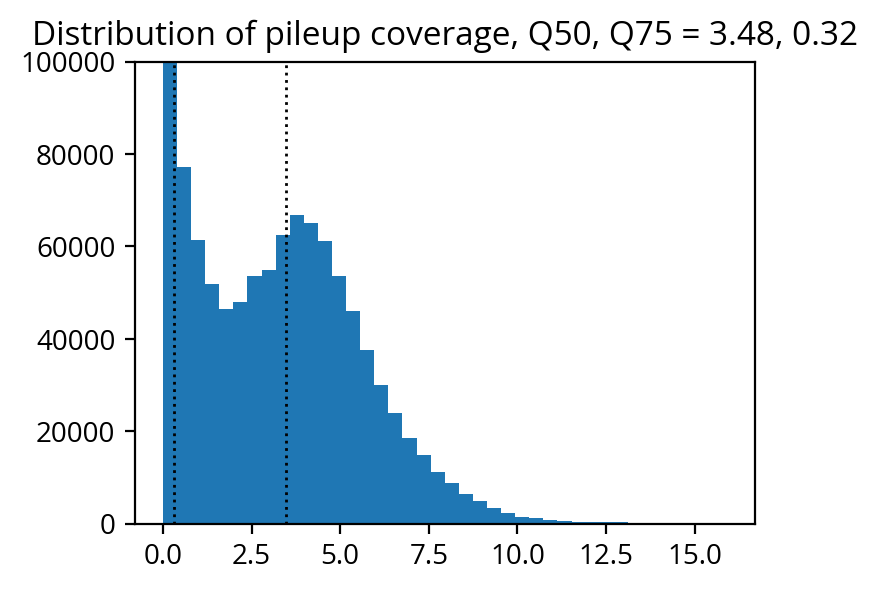

In [961]:
full_combined_strand_pileup_data = np.concatenate([full_w_log_pileup, full_c_log_pileup])
q75, q50 = np.quantile(full_combined_strand_pileup_data, q=[0.75, 0.50])

plt.figure(figsize=(4, 3))
plt.hist(full_combined_strand_pileup_data, bins=40)
plt.ylim(0, 1e5)
plt.axvline(q75, c='black', ls='dotted', lw=1)
plt.axvline(q50, c='black', ls='dotted', lw=1)
plt.title(f"Distribution of pileup coverage, Q50, Q75 = {q75:.2f}, {q50:.2f}")

q75, q50



In [941]:
import numpy as np
from typing import List, Tuple
from src.timer import Timer

def find_transcript_boundaries(pileup_values: np.ndarray, 
                             primary_threshold: float = 3.0,
                             extension_threshold: float = 1.5,
                             min_length: int = 100,
                             max_gap: int = 50,
                             debug: bool = False) -> List[Tuple[int, int]]:
    """
    Optimized transcript boundary identification using vectorized operations.
    
    Parameters:
    -----------
    pileup_values : np.ndarray
        1D array of smoothed pileup coverage values
    primary_threshold : float
        Higher threshold for identifying transcript cores
    extension_threshold : float  
        Lower threshold for extending transcript boundaries
    min_length : int
        Minimum transcript length in base pairs
    max_gap : int
        Maximum gap size to merge nearby regions
    debug : bool
        Print detailed debugging information
        
    Returns:
    --------
    List[Tuple[int, int]]
        List of (start, end) coordinates for identified transcripts
    """
    timer = Timer()
    timer.print_time("Starting transcript boundary detection")
    
    # Check for problematic thresholds
    if extension_threshold <= 0:
        timer.print_time(f"WARNING: Extension threshold of {extension_threshold} may be too permissive!")
    
    # Step 1: Find core regions above primary threshold (vectorized)
    core_mask = pileup_values >= primary_threshold
    core_regions = _get_regions_from_mask_optimized(core_mask)
    
    timer.print_time(f"Found {len(core_regions)} core regions above threshold {primary_threshold}")
    
    if debug and core_regions:
        avg_core_length = np.mean([end - start + 1 for start, end in core_regions])
        timer.print_time(f"DEBUG: Average core region length: {avg_core_length:.1f} bp")
        timer.print_time(f"DEBUG: Core regions span: {core_regions[0][0]} to {core_regions[-1][1]}")
    
    if not core_regions:
        timer.print_time("No core regions found, returning empty list")
        return []
    
    # Step 2: Vectorized extension using extension threshold
    extension_mask = pileup_values >= extension_threshold
    extended_regions = _extend_regions_vectorized(core_regions, extension_mask)
    
    timer.print_time(f"Extended {len(extended_regions)} regions using threshold {extension_threshold}")
    
    if debug and extended_regions:
        avg_extended_length = np.mean([end - start + 1 for start, end in extended_regions])
        timer.print_time(f"DEBUG: Average extended region length: {avg_extended_length:.1f} bp")
        
        # Check for overlapping regions after extension
        overlaps = 0
        for i in range(len(extended_regions) - 1):
            if extended_regions[i][1] >= extended_regions[i+1][0]:
                overlaps += 1
        timer.print_time(f"DEBUG: {overlaps} overlapping regions after extension")
    
    # Step 3: Merge overlapping or nearby regions (optimized)
    merged_regions = _merge_nearby_regions_optimized(extended_regions, max_gap)
    
    timer.print_time(f"Merged to {len(merged_regions)} regions (max_gap: {max_gap})")
    
    if debug and merged_regions:
        avg_merged_length = np.mean([end - start + 1 for start, end in merged_regions])
        timer.print_time(f"DEBUG: Average merged region length: {avg_merged_length:.1f} bp")
        if len(merged_regions) <= 5:
            for i, (start, end) in enumerate(merged_regions):
                timer.print_time(f"DEBUG: Merged region {i+1}: {start}-{end} ({end-start+1} bp)")
    
    # Step 4: Filter by minimum length (vectorized)
    final_regions = _filter_by_length_vectorized(merged_regions, min_length)
    
    timer.print_time(f"Final result: {len(final_regions)} transcripts after length filter (min: {min_length})")
    
    return final_regions


def _get_regions_from_mask_optimized(mask: np.ndarray) -> List[Tuple[int, int]]:
    """Optimized conversion of boolean mask to regions using vectorized operations."""
    if not np.any(mask):
        return []
    
    # Vectorized approach: find all transitions at once
    padded_mask = np.concatenate(([False], mask, [False]))
    diff = np.diff(padded_mask.astype(np.int8))
    
    # Find start and end positions in one operation
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    
    return list(zip(starts, ends))


def _extend_regions_vectorized(regions: List[Tuple[int, int]], 
                             extension_mask: np.ndarray) -> List[Tuple[int, int]]:
    """Vectorized region extension - much faster than position-by-position loops."""
    if not regions:
        return []
    
    extended_regions = []
    mask_length = len(extension_mask)
    
    # Convert to numpy for faster processing
    regions_array = np.array(regions)
    
    for start, end in regions_array:
        # Vectorized left extension
        if start > 0:
            # Find the leftmost position where extension_mask becomes False
            left_chunk = extension_mask[:start][::-1]  # Reverse for cumsum
            if len(left_chunk) > 0:
                # Find first False in reversed array
                false_positions = np.where(~left_chunk)[0]
                if len(false_positions) > 0:
                    extended_start = start - false_positions[0]
                else:
                    extended_start = 0
            else:
                extended_start = start
        else:
            extended_start = start
            
        # Vectorized right extension
        if end < mask_length - 1:
            # Find the rightmost position where extension_mask becomes False
            right_chunk = extension_mask[end + 1:]
            if len(right_chunk) > 0:
                false_positions = np.where(~right_chunk)[0]
                if len(false_positions) > 0:
                    extended_end = end + false_positions[0]
                else:
                    extended_end = mask_length - 1
            else:
                extended_end = end
        else:
            extended_end = end
            
        extended_regions.append((extended_start, extended_end))
    
    return extended_regions


def _merge_nearby_regions_optimized(regions: List[Tuple[int, int]], 
                                  max_gap: int) -> List[Tuple[int, int]]:
    """Optimized merging using numpy operations."""
    if not regions:
        return []
    
    if len(regions) == 1:
        return regions
    
    # Convert to numpy array for vectorized operations
    regions_array = np.array(sorted(regions))
    starts = regions_array[:, 0]
    ends = regions_array[:, 1]
    
    # Vectorized gap calculation
    gaps = starts[1:] - ends[:-1] - 1
    
    # Find regions that should be merged (gap <= max_gap)
    merge_mask = gaps <= max_gap
    
    # Build merged regions efficiently
    merged = []
    current_start = starts[0]
    current_end = ends[0]
    
    for i, should_merge in enumerate(merge_mask):
        if should_merge:
            # Extend current region
            current_end = max(current_end, ends[i + 1])
        else:
            # Finish current region and start new one
            merged.append((current_start, current_end))
            current_start = starts[i + 1]
            current_end = ends[i + 1]
    
    # Add the last region
    merged.append((current_start, current_end))
    
    return merged


def _filter_by_length_vectorized(regions: List[Tuple[int, int]], 
                                min_length: int) -> List[Tuple[int, int]]:
    """Vectorized length filtering."""
    if not regions:
        return []
    
    # Convert to numpy for vectorized length calculation
    regions_array = np.array(regions)
    lengths = regions_array[:, 1] - regions_array[:, 0] + 1
    
    # Vectorized filtering
    valid_mask = lengths >= min_length
    valid_regions = regions_array[valid_mask]
    
    return [tuple(region) for region in valid_regions]


def find_transcript_boundaries_batch(pileup_arrays: List[np.ndarray],
                                   primary_threshold: float = 3.0,
                                   extension_threshold: float = 1.5,
                                   min_length: int = 100,
                                   max_gap: int = 50) -> List[List[Tuple[int, int]]]:
    """
    Batch processing version for multiple chromosomes/samples.
    More efficient when processing many arrays.
    """
    timer = Timer()
    timer.print_time(f"Starting batch transcript detection on {len(pileup_arrays)} arrays")
    
    all_results = []
    
    for i, pileup_values in enumerate(pileup_arrays):
        if i % 5 == 0:  # Progress every 5 arrays
            timer.print_time(f"Processing array {i+1}/{len(pileup_arrays)}")
        
        results = find_transcript_boundaries(
            pileup_values, primary_threshold, extension_threshold, min_length, max_gap
        )
        all_results.append(results)
    
    timer.print_time("Completed batch transcript detection")
    return all_results


# Advanced version with even more optimizations
def find_transcript_boundaries_ultra_fast(pileup_values: np.ndarray, 
                                        primary_threshold: float = 3.0,
                                        extension_threshold: float = 1.5,
                                        min_length: int = 100,
                                        max_gap: int = 50) -> List[Tuple[int, int]]:
    """
    Ultra-optimized version using advanced numpy techniques.
    Use this for very large chromosomes or when speed is critical.
    """
    timer = Timer()
    timer.print_time("Starting ultra-fast transcript boundary detection")
    
    # Step 1: Vectorized core and extension mask creation
    core_mask = pileup_values >= primary_threshold
    extension_mask = pileup_values >= extension_threshold
    
    if not np.any(core_mask):
        timer.print_time("No regions above primary threshold found")
        return []
    
    # Step 2: Find all regions in one vectorized operation
    # Use run-length encoding approach
    padded_core = np.concatenate(([False], core_mask, [False]))
    padded_ext = np.concatenate(([False], extension_mask, [False]))
    
    core_diff = np.diff(padded_core.astype(np.int8))
    core_starts = np.where(core_diff == 1)[0]
    core_ends = np.where(core_diff == -1)[0] - 1
    
    timer.print_time(f"Found {len(core_starts)} core regions")
    
    # Step 3: Vectorized extension for all regions simultaneously
    ext_diff = np.diff(padded_ext.astype(np.int8))
    ext_starts = np.where(ext_diff == 1)[0]
    ext_ends = np.where(ext_diff == -1)[0] - 1
    
    # For each core region, find the encompassing extension region
    extended_regions = []
    for core_start, core_end in zip(core_starts, core_ends):
        # Find extension region that contains this core
        ext_left = ext_starts[ext_starts <= core_start]
        ext_right = ext_ends[ext_ends >= core_end]
        
        if len(ext_left) > 0 and len(ext_right) > 0:
            extended_start = ext_left[-1]  # Rightmost start <= core_start
            extended_end = ext_right[0]    # Leftmost end >= core_end
            extended_regions.append((extended_start, extended_end))
    
    timer.print_time(f"Extended to {len(extended_regions)} regions")
    
    # Step 4: Ultra-fast merging and filtering
    if not extended_regions:
        return []
    
    # Convert to structured array for maximum speed
    dtype = [('start', np.int32), ('end', np.int32)]
    regions_struct = np.array(extended_regions, dtype=dtype)
    regions_struct.sort(order='start')
    
    # Vectorized merging
    if len(regions_struct) > 1:
        gaps = regions_struct['start'][1:] - regions_struct['end'][:-1] - 1
        merge_points = np.where(gaps > max_gap)[0] + 1
        
        # Split at merge points and merge each segment
        segments = np.split(regions_struct, merge_points)
        merged_regions = []
        
        for segment in segments:
            if len(segment) > 0:
                merged_start = segment['start'][0]
                merged_end = segment['end'][-1]
                merged_regions.append((merged_start, merged_end))
    else:
        merged_regions = extended_regions
    
    # Vectorized length filtering
    final_regions = [(s, e) for s, e in merged_regions if e - s + 1 >= min_length]
    
    timer.print_time(f"Final result: {len(final_regions)} transcripts after ultra-fast processing")
    
    return final_regions

In [942]:
len(full_w_log_pileup)

948066

In [945]:
full_w_transcripts = find_transcript_boundaries(
    full_w_log_pileup, 
    primary_threshold=q75,
    extension_threshold=q50,
    min_length=100,
    max_gap=50
)

full_c_transcripts = find_transcript_boundaries(
    full_c_log_pileup, 
    primary_threshold=q75,
    extension_threshold=q50,
    min_length=100,
    max_gap=50
)


Starting transcript boundary detection - 00:00:00.000
Found 3341 core regions above threshold 3.4838157772642564 - 00:00:00.002
Extended 3341 regions using threshold 0.32192809488736235 - 00:00:03.110
Merged to 279 regions (max_gap: 50) - 00:00:03.113
Final result: 258 transcripts after length filter (min: 100) - 00:00:03.114
Starting transcript boundary detection - 00:00:00.000
Found 2922 core regions above threshold 3.4838157772642564 - 00:00:00.002
Extended 2922 regions using threshold 0.32192809488736235 - 00:00:02.602
Merged to 251 regions (max_gap: 50) - 00:00:02.604
Final result: 239 transcripts after length filter (min: 100) - 00:00:02.605


(-20.0, 20.0)

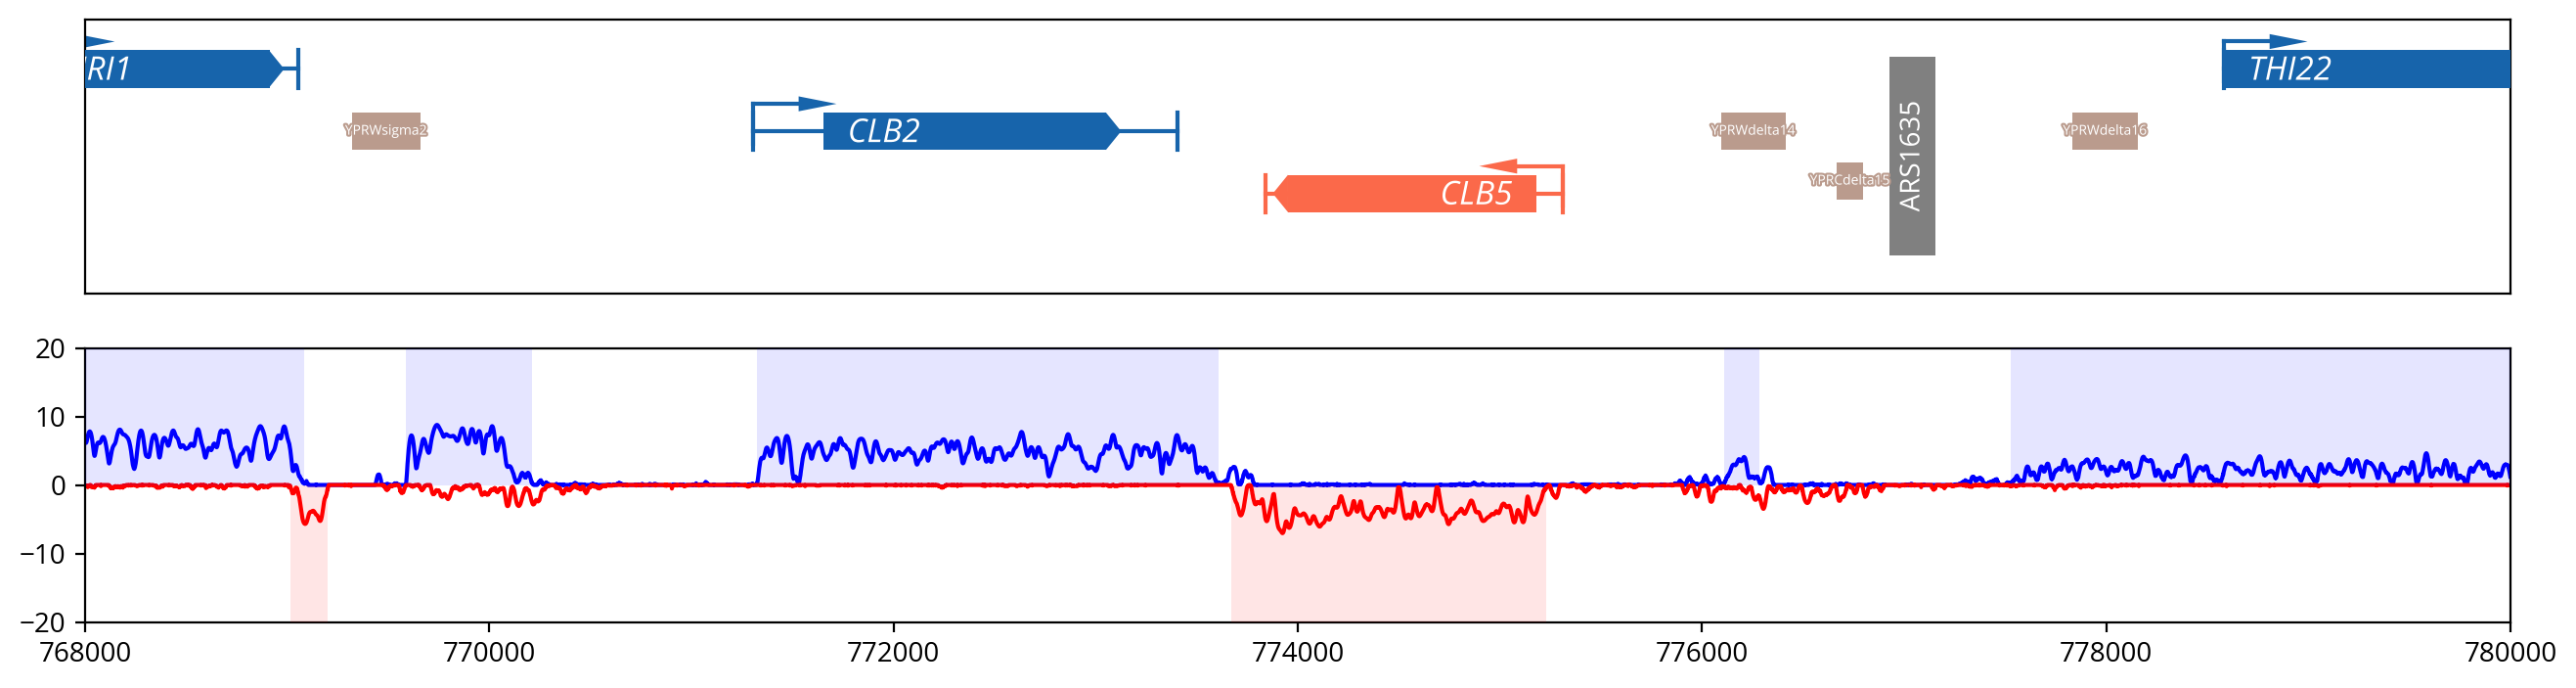

In [959]:
        
plt.figure(figsize=(16, 4))
plt.subplot(2, 1, 1)
orf_plotter.plot_orf_annotations(plt.gca())

plt.subplot(2, 1, 2)

bins_to_plot = np.arange(span[0], span[1])
full_w_log_pileup[bins_to_plot]
plt.plot(bins_to_plot, full_w_log_pileup[span[0]:span[1]], c='blue')
plt.plot(bins_to_plot, -full_c_log_pileup[span[0]:span[1]], c='red')
plt.ylim(-20, 20)
plt.xlim(span[0], span[1])

ax = plt.gca()
for transcript_span in full_w_transcripts:
    if transcript_span[1] > span[0] and transcript_span[0] < span[1]:
        plot_rect2(ax, transcript_span[0], 0, transcript_span[1], 
               20, color='blue', alpha=0.1)
        
for transcript_span in full_c_transcripts:
    if transcript_span[1] > span[0] and transcript_span[0] < span[1]:
        plot_rect2(ax, transcript_span[0], 0, transcript_span[1], 
               -20, color='red', alpha=0.1)
        
plt.xlim(span[0], span[1])
plt.ylim(-20, 20)

In [1041]:
from src.transcript_boundary_caller import AntisenseTranscriptCaller
from src.timer import Timer

timer = Timer()

chrom = 16
caller = AntisenseTranscriptCaller(
    chromosome=chrom,
    min_length=80,                      # Minimum transcript length
    max_gap=120,                         # Maximum gap to merge regions
    timer=timer
)


In [1042]:
caller.load_pileup_from_bam(all_chrom_reads_rep1, all_chrom_reads_rep2,
    chrom_len, smooth=True)

Starting pileup computation for chromosome 16 - 00:00:00.000
Completed pileup computation and replicate averaging - 00:00:52.988


In [1048]:
results_df = caller.detect_transcript_boundaries(strand='both')
results_df = caller.annotate_transcript_gene_overlap() # Assign to gene annotations
print(f"Detected {len(results_df)} transcripts")

Starting transcript boundary detection - 00:03:16.189
Calculated quantile thresholds: primary=1.051 (Q0.25), extension=0.280 (Q0.1) - 00:03:16.594
Found 312 Watson transcripts - 00:03:18.178
Found 332 Crick transcripts - 00:03:19.776
Completed boundary detection: 644 total transcripts - 00:03:19.782
Starting transcript gene annotation with 100bp buffer - 00:03:20.003
Found 511 genes on chromosome 16 - 00:03:20.005
Annotation complete: 393 transcripts overlap with genes, 251 are non-overlapping (potential antisense/intergenic) - 00:03:23.107
Detected 644 transcripts


In [1044]:
from src.transcript_boundary_visualizer import AntisenseTranscriptVisualizer

visualizer = AntisenseTranscriptVisualizer(
    transcript_caller=caller,
    orf_plotter=orf_plotter,
)


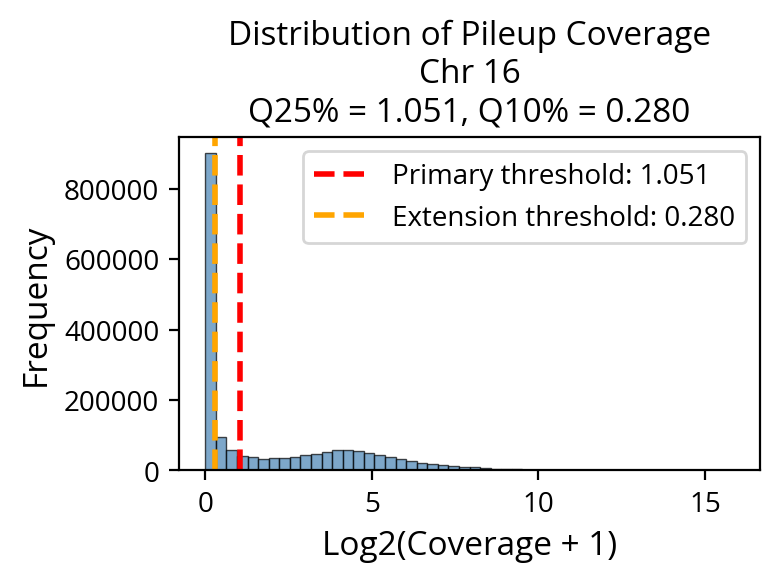

In [1045]:
# 1. Plot threshold distribution to validate parameter choices
fig1 = visualizer.plot_threshold_distribution()


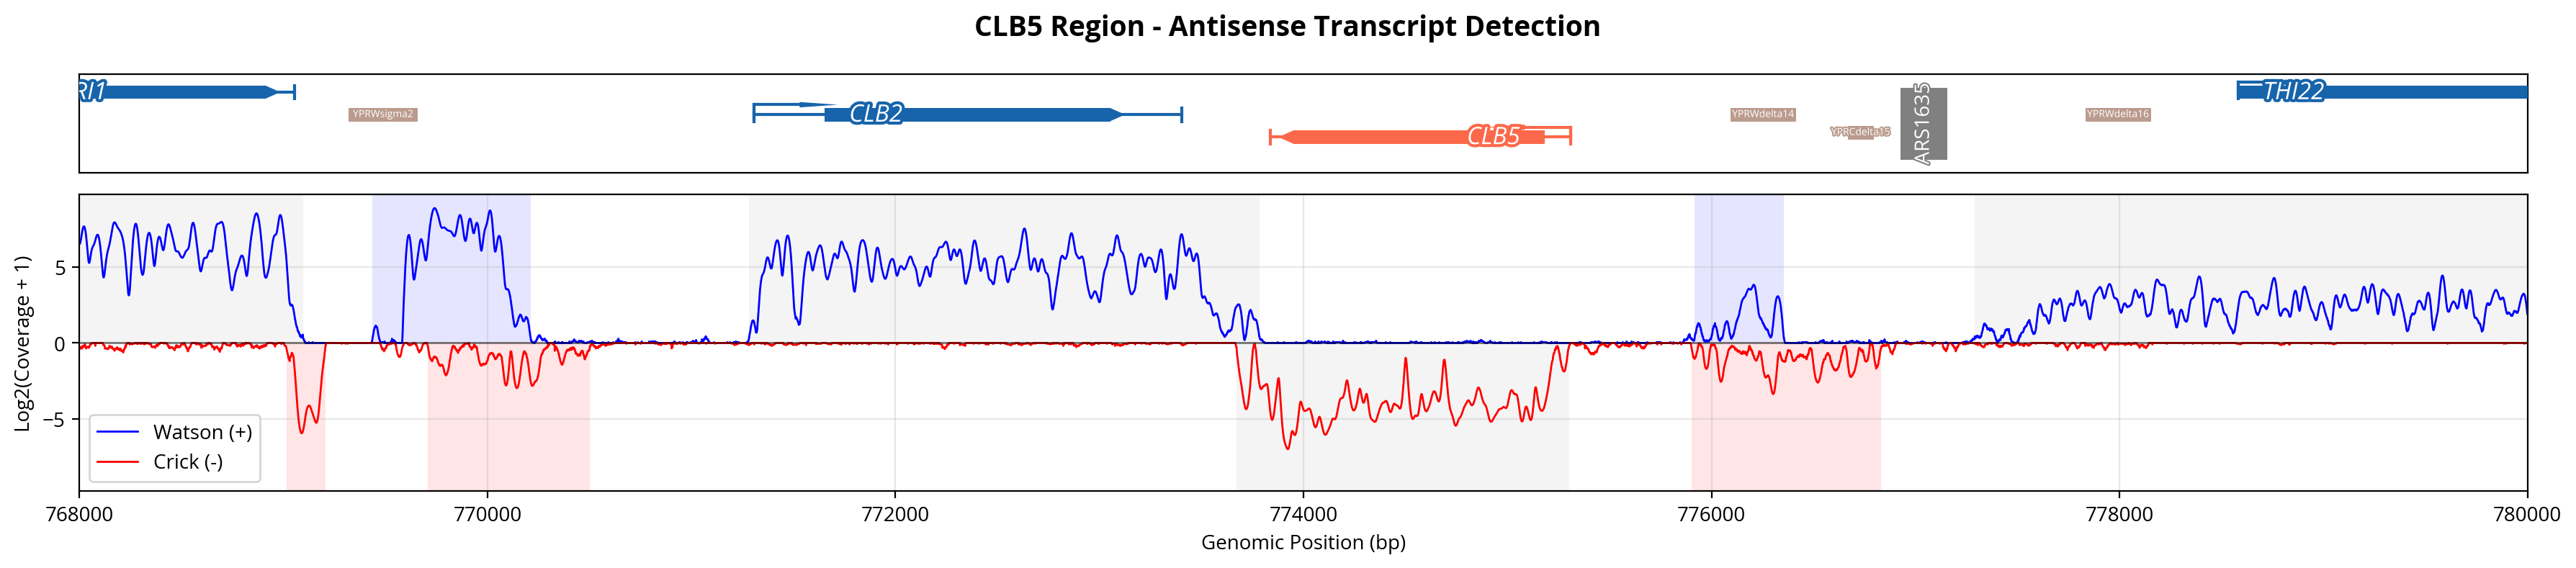

In [1049]:

# 2. Plot region validation (like your CLB5 region)
clb5_region = (768000, 780000)  # Example coordinates
fig2 = visualizer.plot_region_validation(
    span=clb5_region,
    show_orf_annotations=True,
    show_transcript_boundaries=True,
    title="CLB5 Region - Antisense Transcript Detection"
)


In [1057]:
from pipeline.run_pipeline import WINDOWS_ALL_10K_PATH

all_windows_10k = pd.read_csv(WINDOWS_ALL_10K_PATH)

In [1064]:
all_windows_10k[(all_windows_10k.chr == 16) & (all_windows_10k.start == 770000)]

,chr,start,end
1198,16,770000,780000


In [1063]:
chrom

16